# Predicción de Lluvia en Australia — PCA + Regresión Logística
**Inteligencia Artificial I | Fundación Universitaria Los Libertadores — 2024**

Integrantes: Ariza Vargas Sariaht E. X. · Carreño Medina Adriana L. · Linares Viasus Brandon F.

**Fuente de datos:** Bureau of Meteorology, Australia — https://www.bom.gov.au/climate/data/  
**Dataset:** [Rain in Australia — Kaggle](https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package)

---
**Pipeline:** Carga → EDA → Preprocesamiento → PCA → Regresión Logística → Evaluación → Exportación de modelos

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Importaciones y configuración de estilo
Se cargan las librerías necesarias y se define la paleta visual siguiendo los principios de la Unidad 2 (color funcional, paleta cualitativa para clases) y Unidad 3 (data-ink ratio alto, sin chartjunk).

In [21]:
%matplotlib inline
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 72

import warnings; warnings.filterwarnings('ignore')
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)

# ── Paleta visual (Unidad 2: cualitativa para 2 clases; Unidad 3: minimalismo)
BLUE   = "#1565C0"   # clase "Lluvia"
GREEN  = "#2E7D32"   # clase "No lluvia"
ORANGE = "#E65100"   # referencias / líneas secundarias
GRAY   = "#78909C"   # elementos de contexto

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.color":       "#E0E0E0",
    "grid.linewidth":   0.6,
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   13,
    "axes.labelsize":   11,
})

os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../models", exist_ok=True)
print("Entorno listo.")

Entorno listo.


## 2. Carga de datos
Se lee el CSV descargado de Kaggle. La fuente primaria es el Bureau of Meteorology de Australia (https://www.bom.gov.au/climate/data/). El dataset contiene 145 460 observaciones diarias de 49 estaciones meteorológicas entre 2007 y 2017.

In [22]:
DATA_PATH = "/content/drive/MyDrive/data/raw/weatherAUS.csv" # Actualiza esta ruta con la ubicación real de tu archivo
df = pd.read_csv(DATA_PATH)
print(f"Filas: {len(df):,}  |  Columnas: {df.shape[1]}")
print(f"\nValores nulos por columna (top 8):")
print(df.isnull().sum().sort_values(ascending=False).head(8).to_string())
df.head(3)

Filas: 145,460  |  Columnas: 23

Valores nulos por columna (top 8):
Sunshine       69835
Evaporation    62790
Cloud3pm       59358
Cloud9am       55888
Pressure9am    15065
Pressure3pm    15028
WindDir9am     10566
WindGustDir    10326


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No


## 3. Análisis Exploratorio
### 3.1 Distribución de la variable objetivo
Según la Unidad 1, para comparar dos categorías se usa gráfico de barras (no pie). Se aplica paleta cualitativa con dos colores distintos y luminosidad similar (Unidad 2).

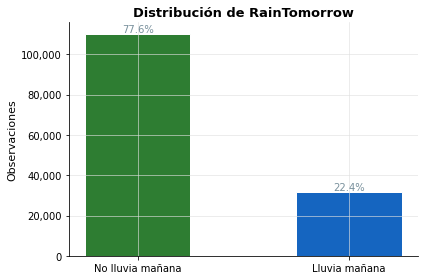

Desbalance: 77.6% No lluvia / 22.4% Lluvia


In [23]:
target_counts = df["RainTomorrow"].value_counts()
pcts = target_counts / target_counts.sum() * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["No lluvia mañana", "Lluvia mañana"],
              target_counts.values,
              color=[GREEN, BLUE], width=0.5, edgecolor="white")

for bar, pct in zip(bars, pcts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f"{pct:.1f}%", ha="center", fontsize=10, color=GRAY)

ax.set_title("Distribución de RainTomorrow", fontweight="bold")
ax.set_ylabel("Observaciones")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("../data/processed/class_distribution.png", dpi=120)
plt.show()
print(f"Desbalance: {pcts.iloc[0]:.1f}% No lluvia / {pcts.iloc[1]:.1f}% Lluvia")

### 3.2 Matriz de correlación
Alta correlación entre variables del mismo tipo (temperatura, presión) justifica el uso de PCA. Paleta divergente `coolwarm` (Unidad 2: adecuada para datos bipolares centrados en cero).

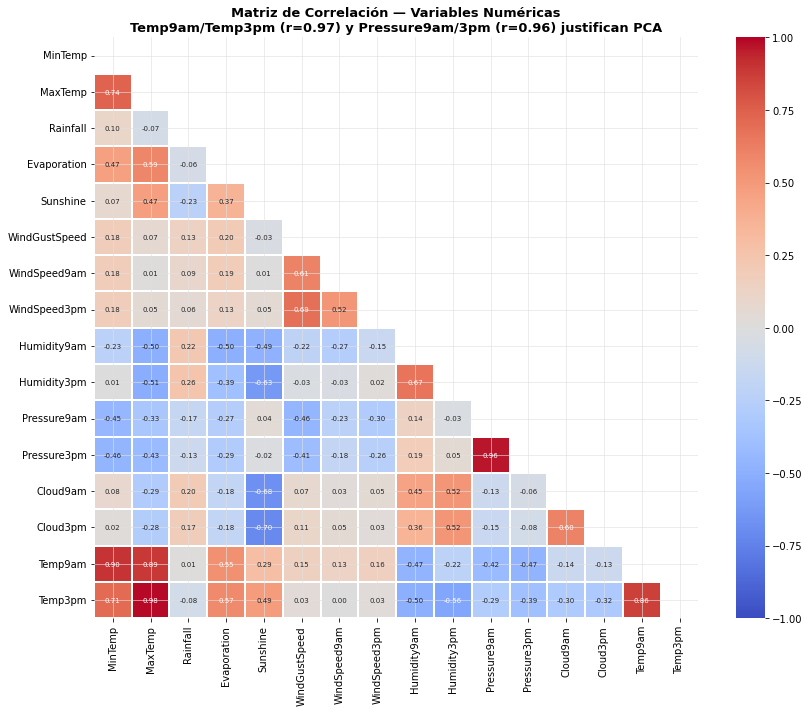

In [24]:
NUMERICAL = ["MinTemp","MaxTemp","Rainfall","Evaporation","Sunshine",
             "WindGustSpeed","WindSpeed9am","WindSpeed3pm",
             "Humidity9am","Humidity3pm","Pressure9am","Pressure3pm",
             "Cloud9am","Cloud3pm","Temp9am","Temp3pm"]

corr = df[NUMERICAL].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, linewidths=0.4,
            annot_kws={"size": 7}, ax=ax)
ax.set_title("Matriz de Correlación — Variables Numéricas\n"
             "Temp9am/Temp3pm (r=0.97) y Pressure9am/3pm (r=0.96) justifican PCA",
             fontweight="bold")
plt.tight_layout()
plt.savefig("../data/processed/correlation_matrix.png", dpi=120)
plt.show()

## 4. Preprocesamiento
El `StandardScaler` y el `PCA` se ajustan **solo sobre train** para evitar data leakage. El target y la variable `RainToday` se codifican como binarios.

In [25]:
FEATURES = NUMERICAL + ["RainToday"]
TARGET   = "RainTomorrow"

data = df[FEATURES + [TARGET]].copy().dropna(subset=[TARGET])
data["RainToday"]   = data["RainToday"].map({"Yes": 1, "No": 0})
data[TARGET]        = data[TARGET].map({"Yes": 1, "No": 0})

# Imputar nulos con mediana (solo variables numéricas)
for col in FEATURES:
    data[col] = data[col].fillna(data[col].median())

X = data[FEATURES].values
y = data[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler     = StandardScaler()
X_train_s  = scaler.fit_transform(X_train)
X_test_s   = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")
print(f"Proporcion lluvia — Train: {y_train.mean()*100:.1f}%  |  Test: {y_test.mean()*100:.1f}%")

Train: 113,754  |  Test: 28,439
Proporcion lluvia — Train: 22.4%  |  Test: 22.4%


## 5. Análisis PCA
### 5.1 Varianza explicada por componente
Se entrena PCA completo sobre train para elegir cuántos componentes retener. Paleta secuencial `Blues` (Unidad 2: para datos continuos ordenados, de menor a mayor varianza acumulada).

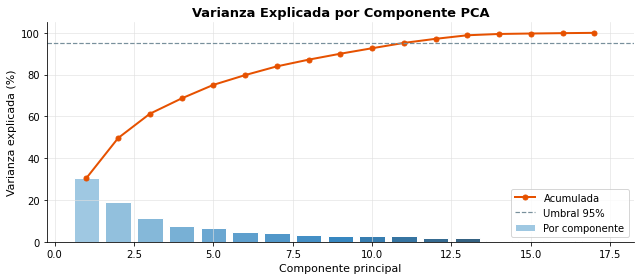

Componentes para 95% de varianza: 11


In [26]:
pca_full = PCA().fit(X_train_s)
ev  = pca_full.explained_variance_ratio_
cum = np.cumsum(ev)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(1, len(ev)+1), ev*100,
       color=sns.color_palette("Blues_d", len(ev)), edgecolor="white", label="Por componente")
ax.plot(range(1, len(ev)+1), cum*100, "o-", color=ORANGE, lw=2, ms=5, label="Acumulada")
ax.axhline(95, color=GRAY, ls="--", lw=1.2, label="Umbral 95%")
ax.set_xlabel("Componente principal")
ax.set_ylabel("Varianza explicada (%)")
ax.set_title("Varianza Explicada por Componente PCA", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/pca_variance.png", dpi=120)
plt.show()
print(f"Componentes para 95% de varianza: {next(i+1 for i,c in enumerate(cum) if c>=0.95)}")

### 5.2 Aplicar PCA con umbral 95%

In [27]:
pca = PCA(n_components=0.95, random_state=42)
X_train_p = pca.fit_transform(X_train_s)
X_test_p  = pca.transform(X_test_s)
print(f"17 features → {pca.n_components_} componentes | Varianza: {sum(pca.explained_variance_ratio_)*100:.2f}%")

17 features → 11 componentes | Varianza: 95.18%


### 5.3 Visualización en espacio PCA
Los dos primeros componentes ya separan parcialmente las clases. Paleta cualitativa (Unidad 2) con dos colores de igual luminosidad.

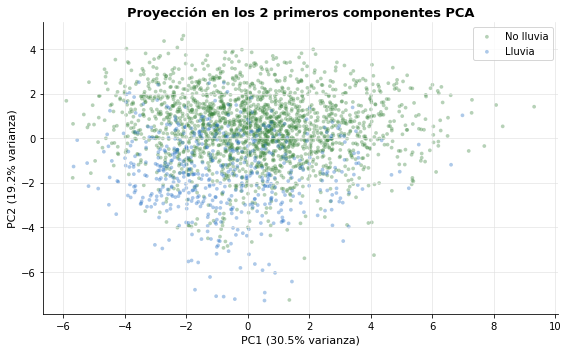

In [28]:
idx = np.random.choice(len(X_train_p), 2500, replace=False)

fig, ax = plt.subplots(figsize=(8, 5))
for cls, color, label in [(0, GREEN, "No lluvia"), (1, BLUE, "Lluvia")]:
    m = y_train[idx] == cls
    ax.scatter(X_train_p[idx][m, 0], X_train_p[idx][m, 1],
               c=color, alpha=0.35, s=14, label=label, edgecolors="none")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)")
ax.set_title("Proyección en los 2 primeros componentes PCA", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/pca_scatter.png", dpi=120)
plt.show()

### 5.4 Variables con mayor peso en PC1
Los loadings indican qué variables originales más contribuyen a cada componente. Barras con color semántico (Unidad 2).

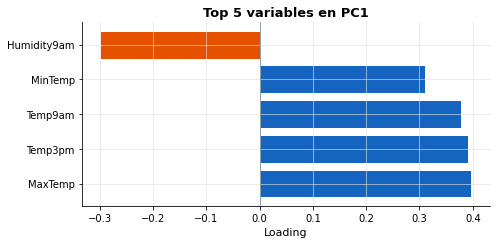

In [29]:
loadings = pd.DataFrame(pca.components_.T,
                        index=FEATURES,
                        columns=[f"PC{i+1}" for i in range(pca.n_components_)])
top5 = loadings["PC1"].abs().nlargest(5)

fig, ax = plt.subplots(figsize=(7, 3.5))
colors = [BLUE if loadings.loc[f,"PC1"] > 0 else ORANGE for f in top5.index]
ax.barh(top5.index, [loadings.loc[f,"PC1"] for f in top5.index],
        color=colors, edgecolor="white")
ax.set_title("Top 5 variables en PC1", fontweight="bold")
ax.set_xlabel("Loading")
ax.axvline(0, color=GRAY, lw=0.8)
plt.tight_layout()
plt.savefig("../data/processed/pca_loadings.png", dpi=120)
plt.show()

## 6. Entrenamiento
Se usa Regresión Logística con `class_weight='balanced'` para compensar el desbalance (77% No lluvia / 23% Lluvia). La validación cruzada 5-fold confirma la estabilidad del modelo.

In [30]:
classifier = LogisticRegression(
    random_state=42, max_iter=2000,
    class_weight="balanced", solver="lbfgs")
classifier.fit(X_train_p, y_train)

pipeline_cv = Pipeline([("scaler", StandardScaler()),
                        ("pca",    PCA(n_components=0.95, random_state=42)),
                        ("clf",    LogisticRegression(random_state=42, max_iter=2000,
                                                      class_weight="balanced"))])
cv_scores = cross_val_score(pipeline_cv, X_train, y_train,
                            cv=StratifiedKFold(5), scoring="roc_auc")
print(f"CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV ROC-AUC: 0.8466 ± 0.0047


## 7. Evaluación del modelo
Métricas sobre el conjunto de prueba (20% estratificado). El Recall es la métrica prioritaria en predicción de lluvia: un falso negativo (predecir sol cuando lloverá) tiene mayor costo que un falso positivo.

In [31]:
y_pred = classifier.predict(X_test_p)
y_prob = classifier.predict_proba(X_test_p)[:, 1]

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_prob)

print("=" * 44)
print("  METRICAS — CONJUNTO TEST")
print("=" * 44)
for name, val in [("Accuracy",acc),("Precision",prec),("Recall",rec),("F1",f1),("ROC-AUC",auc)]:
    print(f"  {name:<12}: {val:.4f}  ({val*100:.2f}%)")

  METRICAS — CONJUNTO TEST
  Accuracy    : 0.7697  (76.97%)
  Precision   : 0.4912  (49.12%)
  Recall      : 0.7627  (76.27%)
  F1          : 0.5975  (59.75%)
  ROC-AUC     : 0.8492  (84.92%)


### 7.1 Matriz de confusión y curva ROC
Diseño aplicando Unidad 3 (data-ink ratio alto, sin bordes decorativos) y Unidad 2 (azul para datos, naranja para referencia — sin rojo/verde en pares engañosos).

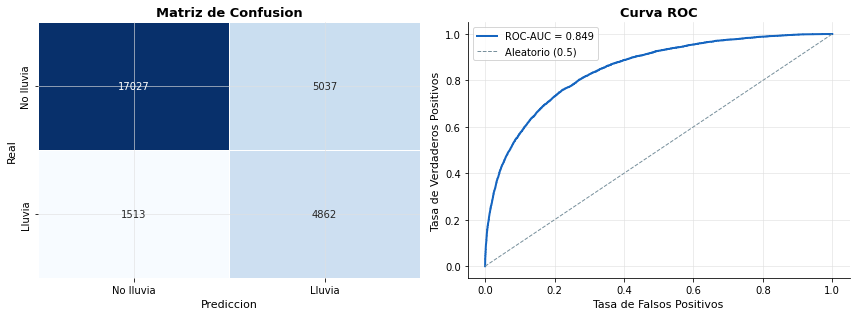

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No lluvia","Lluvia"], yticklabels=["No lluvia","Lluvia"],
            ax=axes[0], cbar=False, linewidths=0.5)
axes[0].set_xlabel("Prediccion"); axes[0].set_ylabel("Real")
axes[0].set_title("Matriz de Confusion", fontweight="bold")

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color=BLUE, lw=2, label=f"ROC-AUC = {auc:.3f}")
axes[1].plot([0,1],[0,1], "--", color=GRAY, lw=1, label="Aleatorio (0.5)")
axes[1].set_xlabel("Tasa de Falsos Positivos")
axes[1].set_ylabel("Tasa de Verdaderos Positivos")
axes[1].set_title("Curva ROC", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.savefig("../data/processed/model_evaluation.png", dpi=120)
plt.show()

### 7.2 Comparación con y sin PCA
Se evalúa el impacto de PCA comparando el rendimiento con distintas configuraciones de componentes.

 Config  Accuracy  ROC-AUC     F1
Sin PCA    0.7906   0.8663 0.6226
6 comp.    0.7627   0.8421 0.5897
    90%    0.7675   0.8461 0.5946
    95%    0.7697   0.8492 0.5975
    99%    0.7858   0.8617 0.6147


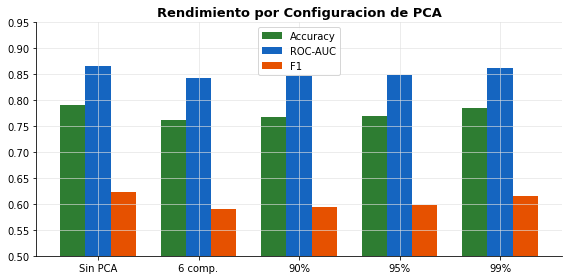

In [33]:
configs = [("Sin PCA",None),("6 comp.",6),("90%",0.90),("95%",0.95),("99%",0.99)]
resultados = []
for nombre, nc in configs:
    steps = [("s", StandardScaler())]
    if nc is not None: steps.append(("p", PCA(n_components=nc, random_state=42)))
    steps.append(("c", LogisticRegression(random_state=42, max_iter=1000,
                                          class_weight="balanced")))
    pipe = Pipeline(steps)
    pipe.fit(X_train, y_train)
    yp, ypr = pipe.predict(X_test), pipe.predict_proba(X_test)[:,1]
    resultados.append({"Config": nombre,
                       "Accuracy": accuracy_score(y_test, yp),
                       "ROC-AUC": roc_auc_score(y_test, ypr),
                       "F1": f1_score(y_test, yp)})

res_df = pd.DataFrame(resultados)
print(res_df.to_string(index=False, float_format="%.4f"))

fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(res_df))
w = 0.25
ax.bar([i-w for i in x], res_df["Accuracy"], width=w, color=GREEN,   label="Accuracy")
ax.bar(list(x),          res_df["ROC-AUC"],  width=w, color=BLUE,    label="ROC-AUC")
ax.bar([i+w for i in x], res_df["F1"],       width=w, color=ORANGE,  label="F1")
ax.set_xticks(list(x)); ax.set_xticklabels(res_df["Config"])
ax.set_ylim(0.5, 0.95)
ax.set_title("Rendimiento por Configuracion de PCA", fontweight="bold")
ax.legend(); plt.tight_layout()
plt.savefig("../data/processed/hyperparameter_comparison.png", dpi=120)
plt.show()

## 8. Exportación de artefactos
Se guardan los objetos ajustados para ser usados directamente por la aplicación Streamlit sin necesidad de reentrenar.

In [34]:
joblib.dump(scaler,     "../models/scaler.pkl")
joblib.dump(pca,        "../models/pca.pkl")
joblib.dump(classifier, "../models/classifier.pkl")
joblib.dump(FEATURES,   "../models/feature_names.pkl")

feature_ranges = {f: {"median": float(np.median(X_train[:, i]))} for i, f in enumerate(FEATURES)}
joblib.dump(feature_ranges, "../models/feature_ranges.pkl")

print("Modelos exportados:")
for f in ["scaler.pkl","pca.pkl","classifier.pkl","feature_names.pkl","feature_ranges.pkl"]:
    size = os.path.getsize(f"../models/{f}") / 1024
    print(f"  {f:<28} {size:.1f} KB")

Modelos exportados:
  scaler.pkl                   1.0 KB
  pca.pkl                      2.8 KB
  classifier.pkl               1.0 KB
  feature_names.pkl            0.2 KB
  feature_ranges.pkl           0.5 KB
